<h1>Núcleo 3 Previsão de Risco de Frustração e Fadiga</h1>
<p>Dataset: <b>ASSISTments 2009</b> (uma linha por interação, processado com Spark)</p>
<p>Aluna: Maria Clara Ribeiro Di Bragança</p>

<h1>Fase 1 Business Understanding</h1>

<h2>Contexto e problema de negócio</h2>
<p>As análises anteriores extraíram propriedades do texto de uma atividade (Núcleo 1) e construíram um Grafo de Conhecimento com o domínio de cada aluno sobre cada conceito (Núcleo 2). Falta uma peça complementar, que é um sinal de alerta precoce: se o aluno está encadeando tentativas mal sucedidas, o risco de frustração e de fadiga aumenta antes do desempenho colapsar, e identificar esse padrão a tempo permite adaptar a atividade (reduzir a dificuldade, trocar o formato ou sugerir uma pausa) antes do aluno abandonar a tarefa.</p>

<h2>Objetivo de negócio</h2>
<p>Avaliar se é possível prever, a partir do histórico recente do aluno em uma sequência de exercícios, se a próxima tentativa tem alta probabilidade de erro. Isso é um proxy comportamental de risco de frustração, porque uma sequência de erros é um precursor observável de desengajamento mesmo sem medir o estado emocional diretamente (esse papel é da pulseira biométrica do sistema, um sinal diferente e complementar, que esta análise não substitui). Como deixar passar um aluno em risco custa mais do que um alarme falso ocasional (a janela de intervenção se fecha sem ninguém perceber), o critério de sucesso não é a acurácia geral, e sim a capacidade de identificar a maior parte dos casos de risco real (recall da classe de risco).</p>

<h2>Objetivo da mineração de dados</h2>
<p>Construir, a partir do log de interações do ASSISTments, features que descrevam o histórico de cada aluno até o momento imediatamente anterior a cada tentativa (sem usar a própria tentativa, o que seria vazamento), comparar classificadores binários liberados nas aulas para prever o erro na tentativa seguinte, ajustar o modelo escolhido para priorizar o recall da classe de risco, e explicar as previsões com SHAP em duas linguagens (professor e responsável).</p>

<h2>Perguntas estratégicas de negócio</h2>
<p>O histórico recente de acerto e tentativas do aluno é suficiente para prever a próxima tentativa acima da linha de base?</p>
<p>Um modelo não linear supera uma referência simples e supera também a Regressão Logística sob as mesmas condições?</p>
<p>Um modelo otimizado sem correção atende o objetivo de sinalizar risco com antecedência, ou é preciso corrigir o treinamento e o threshold para priorizar o recall da classe de risco?</p>
<p>Quais variáveis mais influenciam a previsão, e essa influência é interpretável em termos pedagógicos?</p>

<h1>Fase 2 Data Understanding</h1>

<h2>Por que processar com Spark nesta análise</h2>
<p>As análises anteriores trabalharam com o ASSISTments agregado por aluno e habilidade. Esta análise precisa da granularidade oposta: uma linha por interação individual, em ordem cronológica, para calcular o histórico de cada aluno até o momento imediatamente anterior a cada tentativa. Isso é uma função de janela (window function), com médias móveis por aluno respeitando a ordem das interações, sobre as mais de 270 mil interações do dataset, que é o tipo de operação para o qual o Spark foi feito (agregações particionadas e ordenadas em paralelo). Por isso o Spark é usado aqui e não o pandas, e não por preferência de ferramenta.</p>

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession, Window
from pyspark.sql import functions as F

np.random.seed(42)
DATASETS = "../../datasets/raw"

spark = (
    SparkSession.builder.appName("nucleo3_risco_frustracao")
    .master("local[*]")
    .config("spark.sql.shuffle.partitions", "4")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")
print("Sessão Spark iniciada, versão", spark.version)

Sessão Spark iniciada, versão 4.2.0


In [2]:
assistments = spark.read.parquet(f"{DATASETS}/assistments2009/assistments2009_train.parquet")
print("Total de alunos:", assistments.count())
assistments.printSchema()

tamanhos = assistments.select(F.size("grades").alias("n_interacoes")).toPandas()["n_interacoes"]
print("Total de interações:", int(tamanhos.sum()))
print(tamanhos.describe().round(2))

Total de alunos: 4148
root
 |-- user_id: long (nullable = true)
 |-- skill_ids: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- skill_names: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- grades: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- attempt_counts: array (nullable = true)
 |    |-- element: long (containsNull = true)
 |-- answer_types: array (nullable = true)
 |    |-- element: string (containsNull = true)



Total de interações: 274331
count    4148.00
mean       66.14
std       128.27
min         1.00
25%         8.00
50%        20.00
75%        60.00
max      1040.00
Name: n_interacoes, dtype: float64


<h2>Dicionário de dados</h2>
<p><b>user_id</b>: identificador do aluno.</p>
<p><b>skill_ids e skill_names</b>: listas com o código e o nome do conceito de cada interação.</p>
<p><b>grades</b>: lista de '0' ou '1' (erro ou acerto da interação). É a base da variável alvo.</p>
<p><b>attempt_counts</b>: lista com o número de tentativas em cada interação.</p>
<p><b>answer_types</b>: lista com o formato de resposta esperado (algebra, choose_1, fill_in_1, choose_n, open_response).</p>

In [3]:
dist_acerto = assistments.select(F.explode("grades").alias("grade")).groupBy("grade").count().toPandas().set_index("grade")
dist_acerto["proporção"] = (dist_acerto["count"] / dist_acerto["count"].sum()).round(4)
print("Distribuição de grades (alvo original):")
print(dist_acerto)

dist_tipo = assistments.select(F.explode("answer_types").alias("tipo")).groupBy("tipo").count().toPandas().set_index("tipo")
dist_tipo["proporção"] = (dist_tipo["count"] / dist_tipo["count"].sum()).round(4)
print()
print("Distribuição do tipo de resposta:")
print(dist_tipo.sort_values("count", ascending=False))

tentativas = assistments.select(F.explode("attempt_counts").alias("t")).toPandas()["t"]
print()
print("Tentativas por interação:")
print(tentativas.describe().round(3))
print("Valores ausentes em grades:", assistments.select(F.explode("grades").alias("g")).filter(F.col("g").isNull()).count())

Distribuição de grades (alvo original):
        count  proporção
grade                   
1      181508     0.6616
0       92823     0.3384



Distribuição do tipo de resposta:
                count  proporção
tipo                            
algebra        227079     0.8278
choose_1        29894     0.1090
fill_in_1       17283     0.0630
choose_n           67     0.0002
open_response       8     0.0000



Tentativas por interação:
count    274331.000
mean          1.593
std          13.117
min           0.000
25%           1.000
50%           1.000
75%           1.000
max        3824.000
Name: t, dtype: float64


Valores ausentes em grades: 0


#### Interpretação

<p>O dataset tem 4.148 alunos e 274.331 interações, sem nenhum valor ausente em grades (0%), o que fica abaixo do limite de 1% da regra prática e não é preocupante. A proporção de acertos é 66,16% (181.508 interações) contra 33,84% de erros (92.823), então a classe de risco, que é o erro, é a minoria e a base é desbalanceada de forma moderada, e não extrema. Isso é importante porque uma referência que prevê sempre acerto já teria 66,16% de acurácia sem detectar nenhum aluno em risco, e por isso a acurácia não pode ser a métrica de decisão.</p>
<p>O número de interações por aluno é bem assimétrico (mediana de 20, média de 66,14 e máximo de 1.040), e o formato de resposta é dominado por algebra (82,78%), seguido de choose_1 (10,90%) e fill_in_1 (6,30%), enquanto choose_n (67 linhas) e open_response (8 linhas) são raros demais para o modelo aprender algum padrão a partir deles (a expectativa é que tenham peso quase nulo). Nas tentativas, a média é 1,593 mas o desvio padrão é 13,117 e o máximo é 3.824, o que indica uma cauda longa de valores extremos que pode distorcer médias de tentativas (as árvores lidam bem com isso, mas a Regressão Logística tende a ser mais sensível). Para a próxima etapa, o alvo é claro e as features precisam ser calculadas só com o passado de cada aluno.</p>

<h1>Fase 3 Data Preparation</h1>

<h2>Explosão das listas em interações individuais</h2>
<p><b>O que eu altero:</b> combino as quatro listas paralelas de cada aluno com arrays_zip (uma struct por interação) e transformo cada elemento em uma linha com posexplode, guardando a posição da interação na sequência.</p>
<p><b>Por que preciso alterar:</b> o cálculo do histórico só é possível com uma linha por interação, em ordem, e é essa posição que permite garantir que o histórico use só o que veio antes.</p>
<p><b>Evidência da Fase 2:</b> o alvo (grades) tem só valores 0 e 1, sem ausentes, e as listas de cada aluno têm o mesmo tamanho.</p>
<p><b>Risco de não fazer isso:</b> perder a ordem e misturar interações futuras no histórico.</p>
<p><b>Como verifico:</b> o total de interações depois da explosão precisa bater com o total de antes.</p>

In [4]:
interacoes = (
    assistments.withColumn("interacao", F.arrays_zip("skill_names", "grades", "attempt_counts", "answer_types"))
    .select("user_id", F.posexplode("interacao").alias("posicao", "interacao_struct"))
    .select(
        "user_id", "posicao",
        F.col("interacao_struct.skill_names").alias("skill"),
        F.col("interacao_struct.grades").cast("int").alias("acerto"),
        F.col("interacao_struct.attempt_counts").cast("double").alias("tentativas"),
        F.col("interacao_struct.answer_types").alias("tipo_resposta"),
    )
)
print("Interações depois da explosão:", interacoes.count(), "| antes:", int(tamanhos.sum()))
interacoes.show(5)

Interações depois da explosão: 274331 | antes: 274331


+-------+-------+------------+------+----------+-------------+
|user_id|posicao|       skill|acerto|tentativas|tipo_resposta|
+-------+-------+------------+------+----------+-------------+
|     14|      0|Circle Graph|     0|       1.0|      algebra|
|     14|      1|Circle Graph|     1|       1.0|      algebra|
|     14|      2|Circle Graph|     0|       1.0|      algebra|
|     14|      3|Circle Graph|     0|       1.0|      algebra|
|     14|      4|Circle Graph|     0|       1.0|      algebra|
+-------+-------+------------+------+----------+-------------+
only showing top 5 rows


#### Interpretação

<p>Depois da explosão o total continua em 274.331 interações, igual ao de antes, então nenhuma interação foi perdida ou duplicada. A coluna posicao guarda a ordem de cada interação dentro da sequência do aluno (começando em 0), e nas primeiras linhas do aluno 14 aparecem 5 interações seguidas na skill Circle Graph, com acerto 0, 1, 0, 0, 0. Isso é a base para o cálculo do histórico sem vazamento na próxima etapa, porque é essa ordem que define o que é passado e o que é futuro de cada linha.</p>

<h2>Features históricas por função de janela (sem vazamento)</h2>
<p><b>O que eu altero:</b> para cada interação calculo o histórico do aluno considerando só as interações anteriores a ela, com Window.partitionBy("user_id").orderBy("posicao") e rowsBetween(unboundedPreceding, -1) (o -1 exclui a linha atual). As features são:</p>
<p><b>taxa_acerto_historica</b>: acerto acumulado desde o início da sequência. <b>taxa_acerto_recente</b>: acerto nas últimas 5 tentativas, porque a acumulada dilui uma queda recente. <b>volatilidade_recente</b>: desvio padrão do acerto nas últimas 5. <b>tendencia_desempenho</b>: recente menos acumulada. <b>tentativas_media_historica e tentativas_media_recente</b>: média de tentativas. <b>taxa_acerto_na_habilidade</b> e <b>n_tentativas_habilidade_anteriores</b>: desempenho do aluno na mesma habilidade e o quanto essa taxa é confiável. <b>sequencia_erros_anterior</b>: erros seguidos imediatamente antes (proxy mais direto de frustração do que uma média). <b>posicao</b>: quantos exercícios o aluno já fez (proxy de fadiga acumulada). <b>tipo_resposta</b>: formato esperado da resposta.</p>
<p><b>Por que preciso alterar:</b> o objetivo é prever o erro da tentativa seguinte, então só o passado pode entrar como entrada.</p>
<p><b>Risco de não fazer isso:</b> Data Leakage, porque se a própria tentativa entrar no histórico o modelo recebe o alvo como feature e o resultado fica artificialmente perfeito.</p>
<p><b>Como verifico:</b> recalculando as features em pandas para uma amostra de alunos, com shift(1), e comparando com o resultado do Spark.</p>

In [5]:
janela_historico = Window.partitionBy("user_id").orderBy("posicao").rowsBetween(Window.unboundedPreceding, -1)
JANELA_RECENTE_TAMANHO = 5
janela_recente = Window.partitionBy("user_id").orderBy("posicao").rowsBetween(-JANELA_RECENTE_TAMANHO, -1)
janela_habilidade = Window.partitionBy("user_id", "skill").orderBy("posicao").rowsBetween(Window.unboundedPreceding, -1)
janela_ate_atual = Window.partitionBy("user_id").orderBy("posicao").rowsBetween(Window.unboundedPreceding, 0)
janela_por_aluno = Window.partitionBy("user_id").orderBy("posicao")

interacoes_com_historico = (
    interacoes
    .withColumn("n_interacoes_anteriores", F.count("acerto").over(janela_historico))
    .withColumn("taxa_acerto_historica", F.avg("acerto").over(janela_historico))
    .withColumn("taxa_acerto_recente", F.avg("acerto").over(janela_recente))
    .withColumn("volatilidade_recente", F.stddev(F.col("acerto")).over(janela_recente))
    .withColumn("tentativas_media_historica", F.avg("tentativas").over(janela_historico))
    .withColumn("tentativas_media_recente", F.avg("tentativas").over(janela_recente))
    .withColumn("taxa_acerto_na_habilidade", F.avg("acerto").over(janela_habilidade))
    .withColumn("n_tentativas_habilidade_anteriores", F.count("acerto").over(janela_habilidade))
    # sequência de erros por "grupo por run": grp soma os acertos até a linha atual, então cada sequência
    # de erros seguidos cai no mesmo grupo, e o row_number dentro do grupo dá o tamanho da sequência
    .withColumn("grupo_streak", F.sum(F.col("acerto")).over(janela_ate_atual))
    .withColumn("posicao_no_grupo", F.row_number().over(Window.partitionBy("user_id", "grupo_streak").orderBy("posicao")))
    .withColumn(
        "sequencia_erros_atual",
        F.when(F.col("grupo_streak") == 0, F.col("posicao_no_grupo")).otherwise(F.col("posicao_no_grupo") - 1),
    )
    # o lag garante que a feature use a sequência até a linha anterior, nunca a atual
    .withColumn("sequencia_erros_anterior", F.coalesce(F.lag("sequencia_erros_atual", 1).over(janela_por_aluno), F.lit(0)))
    .drop("grupo_streak", "posicao_no_grupo", "sequencia_erros_atual")
)

interacoes_com_historico.select(
    "user_id", "posicao", "acerto", "n_interacoes_anteriores", "taxa_acerto_recente",
    "volatilidade_recente", "sequencia_erros_anterior", "taxa_acerto_na_habilidade",
).show(8)

+-------+-------+------+-----------------------+-------------------+--------------------+------------------------+-------------------------+
|user_id|posicao|acerto|n_interacoes_anteriores|taxa_acerto_recente|volatilidade_recente|sequencia_erros_anterior|taxa_acerto_na_habilidade|
+-------+-------+------+-----------------------+-------------------+--------------------+------------------------+-------------------------+
|  54318|      0|     0|                      0|               NULL|                NULL|                       0|                     NULL|
|  54318|      1|     1|                      1|                0.0|                NULL|                       1|                      0.0|
|  54318|      2|     1|                      2|                0.5|  0.7071067811865476|                       0|                      0.5|
|  54318|      3|     1|                      3| 0.6666666666666666|  0.5773502691896258|                       0|       0.6666666666666666|
|  54318|    

In [6]:
def streak_anterior(acertos):
    saida, atual = [], 0
    for a in acertos:
        saida.append(atual)
        atual = atual + 1 if a == 0 else 0
    return saida

ids_amostra = [r["user_id"] for r in assistments.select("user_id").sample(fraction=0.05, seed=42).limit(200).collect()]
chk = (
    interacoes_com_historico.filter(F.col("user_id").isin(ids_amostra))
    .select("user_id", "posicao", "acerto", "taxa_acerto_historica", "taxa_acerto_recente", "sequencia_erros_anterior")
    .toPandas().sort_values(["user_id", "posicao"]).reset_index(drop=True)
)
grupo = chk.groupby("user_id")["acerto"]
manual_historica = grupo.transform(lambda s: s.shift(1).expanding().mean())
manual_recente = grupo.transform(lambda s: s.shift(1).rolling(5, min_periods=1).mean())
manual_streak = grupo.transform(lambda s: pd.Series(streak_anterior(s.values), index=s.index))

def diferenca_maxima(spark_col, manual):
    return float(np.nanmax(np.abs(chk[spark_col].astype(float) - manual.astype(float))))

print("Alunos na amostra de verificação:", chk["user_id"].nunique(), "| interações:", len(chk))
print("Diferença máxima, taxa_acerto_historica:", diferenca_maxima("taxa_acerto_historica", manual_historica))
print("Diferença máxima, taxa_acerto_recente:", diferenca_maxima("taxa_acerto_recente", manual_recente))
print("Diferença máxima, sequencia_erros_anterior:", diferenca_maxima("sequencia_erros_anterior", manual_streak))

Alunos na amostra de verificação: 200 | interações: 13217
Diferença máxima, taxa_acerto_historica: 0.0
Diferença máxima, taxa_acerto_recente: 0.0
Diferença máxima, sequencia_erros_anterior: 0.0


#### Interpretação

<p>Em uma amostra de 200 alunos (13.217 interações), a diferença máxima entre as features calculadas no Spark e as recalculadas de forma independente em pandas (com shift(1)) é 0,0 nas três features testadas: taxa_acerto_historica, taxa_acerto_recente e sequencia_erros_anterior. Ou seja, os valores batem exatamente, e isso confirma que a janela do Spark não usa a linha atual, pois se usasse a diferença apareceria já na primeira interação de cada aluno.</p>
<p>Isso mostra que a lógica de tempo está correta em relação à coluna posicao, mas não confirma que a ordem das listas do dataset é a ordem cronológica real das interações (o ASSISTments 2009 usado aqui não tem timestamp), e esse é um limite que fica registrado na conclusão.</p>

<h2>Histórico mínimo, habilidades e valor de reserva</h2>
<p><b>O que eu altero:</b> mantenho só interações com pelo menos 5 interações anteriores, agrupo as 10 habilidades mais frequentes e junto o resto em "outra", preencho a taxa de acerto na habilidade com a taxa acumulada geral quando o aluno ainda não teve nenhuma tentativa naquela habilidade, e crio a tendência de desempenho.</p>
<p><b>Por que preciso alterar:</b> uma taxa calculada com poucas interações é instável (mesmo raciocínio do filtro de interações mínimas do Núcleo 2), codificar centenas de habilidades como colunas separadas não é viável, e o modelo não aceita valor ausente.</p>
<p><b>Evidência da Fase 2:</b> o alvo não tem valores ausentes, então os nulos que aparecem são só do início das sequências (primeiras interações sem histórico) ou da primeira vez na habilidade.</p>
<p><b>Risco de não fazer isso:</b> treinar com muitas linhas sem histórico confiável, o que adiciona ruído.</p>
<p><b>Como verifico:</b> medindo a proporção de linhas que usaram o valor de reserva e conferindo que não sobra nulo nas features.</p>

In [7]:
MINIMO_HISTORICO = 5
base_filtrada = interacoes_com_historico.filter(F.col("n_interacoes_anteriores") >= MINIMO_HISTORICO)

# a escolha das 10 habilidades usa só a contagem de linhas (não olha o alvo), então não vaza informação do teste
top_skills = [r["skill"] for r in base_filtrada.groupBy("skill").count().orderBy(F.desc("count")).limit(10).collect()]

n_base = base_filtrada.count()
n_reserva = base_filtrada.filter(F.col("taxa_acerto_na_habilidade").isNull()).count()

base_com_skill_top = (
    base_filtrada
    .withColumn("skill_agrupada", F.when(F.col("skill").isin(top_skills), F.col("skill")).otherwise(F.lit("outra")))
    .withColumn("taxa_acerto_na_habilidade", F.coalesce(F.col("taxa_acerto_na_habilidade"), F.col("taxa_acerto_historica")))
    .withColumn("tendencia_desempenho", F.col("taxa_acerto_recente") - F.col("taxa_acerto_historica"))
)

print("Interações antes do filtro:", interacoes.count(), "| depois:", n_base)
print(f"Linhas que usaram o valor de reserva na habilidade: {n_reserva} ({n_reserva / n_base:.1%})")
print("Habilidades mantidas individualmente:", top_skills)

Interações antes do filtro: 274331 | depois: 255003
Linhas que usaram o valor de reserva na habilidade: 27791 (10.9%)
Habilidades mantidas individualmente: ['Equation Solving Two or Fewer Steps', 'Conversion of Fraction Decimals Percents', 'Addition and Subtraction Integers', 'Addition and Subtraction Fractions', 'Equation Solving More Than Two Steps', 'Proportion', 'Subtraction Whole Numbers', 'Multiplication and Division Integers', 'Pythagorean Theorem', 'Table']


#### Interpretação

<p>O filtro de pelo menos 5 interações anteriores tira 19.328 linhas (7,05% do total), sobrando 255.003 interações, e essa é a perda esperada, pois são as primeiras interações de cada aluno. Entre as linhas que ficaram, 27.791 (10,9%) usaram o valor de reserva na taxa de acerto na habilidade, ou seja, eram a primeira vez do aluno naquela habilidade e não tinham histórico especifico. As 10 habilidades mais frequentes ficaram individuais, com Equation Solving Two or Fewer Steps e Conversion of Fraction Decimals Percents entre elas, e o resto foi agrupado em "outra".</p>
<p>Com 10,9% das linhas usando o valor de reserva, o preenchimento é uma decisão que tem efeito real (não é um detalhe pequeno), mas é o melhor palpite disponível para esses casos (o desempenho geral do aluno) e o modelo consegue distinguir essas linhas, porque n_tentativas_habilidade_anteriores vale 0 nelas. A escolha das 10 habilidades usa só a contagem de linhas e não o alvo, então não vaza informação do teste.</p>

<h2>Conversão para pandas e encoding</h2>
<p><b>O que eu altero:</b> trago o resultado do Spark para o pandas (o processamento pesado já foi feito) e transformo o tipo de resposta em colunas binárias (one-hot). A habilidade fica guardada como texto (e não vira colunas binárias), porque a dificuldade dela é calculada na Fase 4, dentro do Pipeline, só com dados de treino, e essa única coluna resume o efeito da habilidade sem criar mais 11 colunas. Também redefino o alvo como <b>risco</b> (1 quando o aluno erra, 0 quando acerta), que é o inverso de acerto mas mais direto para o que se quer detectar.</p>
<p><b>Por que preciso alterar:</b> as bibliotecas de modelagem (scikit-learn, XGBoost, LightGBM) trabalham em memória e a base filtrada tem tamanho adequado para isso. O one-hot do tipo de resposta é seguro contra vazamento porque só depende da própria linha, e não de estatísticas de outras.</p>
<p><b>Risco de não fazer isso:</b> deixar a dificuldade da habilidade calculada com a base inteira antes do split, o que faria a média do alvo do teste entrar no treino.</p>
<p><b>Como verifico:</b> conferindo o formato final e que nenhuma feature tem valor ausente.</p>

In [8]:
colunas_base = [
    "user_id", "posicao", "acerto",
    "taxa_acerto_historica", "taxa_acerto_recente", "volatilidade_recente", "tendencia_desempenho",
    "tentativas_media_historica", "tentativas_media_recente",
    "taxa_acerto_na_habilidade", "n_tentativas_habilidade_anteriores", "sequencia_erros_anterior",
    "skill_agrupada", "tipo_resposta",
]
base_pd = base_com_skill_top.select(colunas_base).toPandas()
spark.stop()

base_pd = base_pd.join(base_pd["tipo_resposta"].str.get_dummies()).drop(columns=["tipo_resposta"])
base_pd["risco"] = 1 - base_pd["acerto"]

FEATURES = [c for c in base_pd.columns if c not in ("user_id", "acerto", "risco")]
print("Formato final:", base_pd.shape)
print("Features na entrada (a dificuldade da habilidade entra depois, no Pipeline):", len(FEATURES) - 1, "+ skill_agrupada")
print("Valores ausentes nas features:", int(base_pd[FEATURES].isnull().sum().sum()))
print(f"Proporção da classe de risco (erro): {base_pd['risco'].mean():.1%}")
print("Alunos distintos:", base_pd["user_id"].nunique())

Formato final: (255003, 19)
Features na entrada (a dificuldade da habilidade entra depois, no Pipeline): 15 + skill_agrupada
Valores ausentes nas features: 0
Proporção da classe de risco (erro): 33.7%
Alunos distintos: 3452


#### Interpretação

<p>A base final tem 255.003 linhas e 19 colunas (o identificador do aluno, o acerto, o risco e 16 colunas de entrada, sendo 15 features prontas mais a habilidade em texto), sem nenhum valor ausente nas features (0 ausentes). A proporção da classe de risco é de 33,7% e o número de alunos distintos é 3.452, contra 4.148 no dataset original, ou seja, 696 alunos (16,8%) saíram por terem 5 interações ou menos e nunca chegarem ao histórico mínimo.</p>
<p>Isso significa que o modelo só vale para alunos com pelo menos 5 interações de histórico, o que é coerente com o objetivo (o alerta precoce precisa de algum histórico), mas deixa o aluno recém-chegado sem cobertura, e essa é uma limitação para o cold start do sistema.</p>

<h2>Split treino e teste agrupado por aluno e estratificado</h2>
<p><b>O que eu altero:</b> separo treino e teste com StratifiedGroupKFold (primeira dobra, cerca de 20% para teste), de forma que nenhum aluno aparece nos dois lados e a proporção de risco fica preservada o quanto a restrição de grupo permitir.</p>
<p><b>Por que preciso alterar:</b> cada aluno tem centenas de interações. Se a divisão fosse por linha, interações do mesmo aluno cairiam no treino e no teste, e o modelo estaria só reconhecendo o comportamento de alunos que já viu, e não generalizando para um aluno novo (que é o caso de uso real).</p>
<p><b>Evidência da Fase 2:</b> a base é desbalanceada (o risco é a minoria) e cada aluno contribui com muitas linhas.</p>
<p><b>Risco de não fazer isso:</b> Data Leakage entre treino e teste por aluno, com métricas otimistas demais.</p>
<p><b>Como verifico:</b> conferindo que a interseção de alunos entre treino e teste é zero e comparando a proporção de risco nos dois lados.</p>

In [9]:
from sklearn.model_selection import StratifiedGroupKFold

X = base_pd[FEATURES]
y = base_pd["risco"]
grupos = base_pd["user_id"]

divisor = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
idx_treino, idx_teste = next(divisor.split(X, y, groups=grupos))

X_train, X_test = X.iloc[idx_treino], X.iloc[idx_teste]
y_train, y_test = y.iloc[idx_treino], y.iloc[idx_teste]
grupos_train = grupos.iloc[idx_treino]

alunos_treino, alunos_teste = set(grupos_train), set(grupos.iloc[idx_teste])
print(f"Treino: {len(X_train)} linhas, {len(alunos_treino)} alunos | proporção de risco: {y_train.mean():.4f}")
print(f"Teste: {len(X_test)} linhas, {len(alunos_teste)} alunos | proporção de risco: {y_test.mean():.4f}")
print("Alunos presentes nos dois conjuntos (deve ser 0):", len(alunos_treino & alunos_teste))

Treino: 215830 linhas, 2820 alunos | proporção de risco: 0.3363
Teste: 39173 linhas, 632 alunos | proporção de risco: 0.3387
Alunos presentes nos dois conjuntos (deve ser 0): 0


#### Interpretação

<p>O treino ficou com 215.830 linhas e 2.820 alunos (proporção de risco de 0,3363) e o teste com 39.173 linhas e 632 alunos (0,3387), e nenhum aluno aparece nos dois lados (0 alunos em comum). A diferença de proporção de risco entre os dois lados é de só 0,24 ponto percentual, ou seja, a estratificação funcionou mesmo com a restrição de grupo.</p>
<p>O teste ficou com 15,4% das linhas (e 18,3% dos alunos), um pouco abaixo dos 20% pedidos, pois a restrição de grupos inteiros faz o tamanho variar um pouco (os alunos do teste tem em média 62 linhas contra 76 do treino). Isso não é preocupante, e o principal ganho é que o teste representa alunos nunca vistos, que é o caso de uso real.</p>

<h2>Dificuldade média da habilidade: transformador que aprende só no treino</h2>
<p><b>O que eu altero:</b> crio a feature <b>dificuldade_habilidade</b> (proporção de risco de todos os alunos naquela habilidade), mas como um transformador dentro do Pipeline, que calcula a média no fit e aplica no transform.</p>
<p><b>Por que preciso alterar:</b> a feature é calculada a partir do próprio alvo, então precisa ser aprendida só com o treino (e, dentro da validação cruzada, só com o treino de cada dobra). Habilidades que não aparecerem no treino recebem a média geral do treino como valor de reserva.</p>
<p><b>Risco de não fazer isso:</b> a média do alvo de linhas de validação ou teste entraria na feature, um vazamento indireto de alvo.</p>
<p><b>Como verifico:</b> conferindo os valores aprendidos no treino e que a coluna de texto da habilidade sai do X depois da transformação.</p>

In [10]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

class DificuldadeHabilidade(BaseEstimator, TransformerMixin):
    def __init__(self, coluna="skill_agrupada"):
        self.coluna = coluna

    def fit(self, X, y):
        y = pd.Series(np.asarray(y), index=X.index)
        self.media_ = y.groupby(X[self.coluna]).mean()
        self.media_geral_ = y.mean()
        return self

    def transform(self, X):
        X = X.copy()
        X["dificuldade_habilidade"] = X[self.coluna].map(self.media_).fillna(self.media_geral_)
        return X.drop(columns=[self.coluna])

teste_transformador = DificuldadeHabilidade().fit(X_train, y_train)
print("Dificuldade média por habilidade (só treino), da maior para a menor:")
print(teste_transformador.media_.sort_values(ascending=False).round(4))
saida = teste_transformador.transform(X_test)
print()
print("Colunas de X_test depois da transformação:", saida.shape[1], "| coluna de texto removida:", "skill_agrupada" not in saida.columns)
print("Habilidades do teste sem correspondência no treino:", int((~X_test["skill_agrupada"].isin(teste_transformador.media_.index)).sum()))

Dificuldade média por habilidade (só treino), da maior para a menor:
skill_agrupada
Addition and Subtraction Integers           0.4044
Pythagorean Theorem                         0.3720
Conversion of Fraction Decimals Percents    0.3580
Subtraction Whole Numbers                   0.3522
outra                                       0.3438
Proportion                                  0.3418
Addition and Subtraction Fractions          0.3230
Equation Solving Two or Fewer Steps         0.3128
Table                                       0.2576
Equation Solving More Than Two Steps        0.2413
Multiplication and Division Integers        0.2217
dtype: float64

Colunas de X_test depois da transformação: 16 | coluna de texto removida: True
Habilidades do teste sem correspondência no treino: 0


#### Interpretação

<p>A dificuldade média por habilidade, calculada só com o treino, vai de 0,2217 (Multiplication and Division Integers, a mais fácil) até 0,4044 (Addition and Subtraction Integers, a mais difícil), uma diferença de cerca de 1,8 vez entre a mais difícil e a mais fácil. A categoria "outra" (0,3438) fica quase igual à taxa geral de risco do treino (0,3363), o que é coerente, pois ela mistura muitas habilidades. Nenhuma habilidade do teste ficou sem correspondência no treino (0 casos), então o valor de reserva não foi necessário nesta divisão, mas o transformador continua preparado para o caso (importante se a divisão mudar), e a coluna de texto sai do X depois da transformação (16 colunas no total).</p>
<p>Isso confirma que existe um componente de dificuldade da habilidade, diferente do desempenho individual do aluno, e a hipótese é que as habilidades com números negativos (integers) sejam mais difíceis, mas isso não foi testado. Como a feature é aprendida dentro do Pipeline, ela vale tambem para a validação cruzada da próxima fase, e a avaliação não é otimista por causa dela.</p>

<h2>Conclusão da Fase 3</h2>
<p>Deixei pronto para a Fase 4: uma linha por interação com features históricas calculadas sem vazamento (confirmado por recálculo independente em pandas), o alvo redefinido como risco de erro, o split treino e teste agrupado por aluno e estratificado (com zero alunos em comum), e a dificuldade da habilidade encapsulada em um transformador que só aprende com o treino, pronto para entrar no Pipeline de cada modelo.</p>

<h1>Fase 4 Modeling</h1>

<h2>Escolha dos modelos</h2>
<p>Só entram modelos apresentados nas aulas, e aqui são testados 5 deles, todos dentro do mesmo Pipeline (dificuldade da habilidade aprendida em cada dobra):</p>
<p><b>Regressão Logística</b>: fronteira linear, com StandardScaler porque é sensível à escala. É a referência clássica e a mais fácil de explicar, e mostra o quanto se ganha ao capturar interações entre features.</p>
<p><b>Árvore de Decisão</b> (profundidade limitada): divide os alunos por regras simples do tipo "mais de 3 erros seguidos?". Faz sentido testar porque o risco parece depender de combinações de regras, e ela é totalmente interpretável.</p>
<p><b>Random Forest</b>: várias árvores independentes com a média das previsões. Reduz o excesso de ajuste de uma árvore só e mostra o quanto o boosting sequencial ajuda além disso.</p>
<p><b>XGBoost</b>: árvores em sequência, cada uma corrigindo o erro da anterior. Faz sentido porque as features têm interações relevantes (sequência de erros combinada com taxa de acerto, por exemplo).</p>
<p><b>LightGBM</b>: outro boosting, com crescimento de árvore diferente e treino mais rápido. Entra para verificar se o resultado do XGBoost é específico do algoritmo ou comum à família.</p>
<p>O SVC também está liberado, mas fica de fora porque o custo de treino cresce muito com o número de linhas (mais de 200 mil no treino), o que inviabilizaria a validação cruzada.</p>

<h2>Balanceamento de classes</h2>
<p>O risco é a classe minoritária, então cada modelo é comparado sem ajuste e com ajuste de peso de classe (class_weight="balanced" ou scale_pos_weight, que aumenta o peso do erro na classe de risco proporcionalmente ao desbalanceamento). Foi escolhido em vez do SMOTE porque a base é grande e porque interpolar features de histórico geraria sequências de alunos que não existem, sem ganho claro.</p>

<h2>Sobre a prioridade das métricas</h2>
<p>Como a classe de risco é a minoria, priorizo o <b>PR-AUC</b> em primeiro lugar, porque ele avalia o modelo em todos os thresholds e é mais sensível ao desempenho na classe minoritária (que é a que importa) do que o ROC-AUC. A linha de base do PR-AUC é a proporção de risco na base (um modelo aleatório teria PR-AUC igual a essa proporção). Em segundo lugar olho o <b>recall da classe de risco</b>, porque o objetivo de negócio é não deixar passar aluno em risco, e depois o <b>F1</b> e a <b>precision</b>, que mostram o custo em alarmes falsos. O <b>ROC-AUC</b> fica como apoio e a acurácia não é usada para decidir, porque um modelo que nunca sinaliza risco já teria acurácia alta. Todas as decisões desta fase usam previsões fora da dobra (out-of-fold) só no treino, e o teste fica reservado para a Fase 5.</p>

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (average_precision_score, roc_auc_score, precision_score,
                             recall_score, f1_score, precision_recall_curve, roc_curve, confusion_matrix)

peso_classe_risco = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Proporção acerto para risco no treino: {(y_train == 0).sum()} para {(y_train == 1).sum()} | scale_pos_weight = {peso_classe_risco:.3f}")
print(f"Linha de base do PR-AUC (proporção de risco no treino): {y_train.mean():.3f}")

def montar_pipeline(nome, balanceado):
    modelos = {
        "Regressão Logística": LogisticRegression(max_iter=2000, class_weight="balanced" if balanceado else None),
        "Árvore de Decisão": DecisionTreeClassifier(max_depth=6, min_samples_leaf=200, class_weight="balanced" if balanceado else None, random_state=42),
        "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=8, class_weight="balanced" if balanceado else None, random_state=42, n_jobs=-1),
        "XGBoost": XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1, eval_metric="logloss",
                                 scale_pos_weight=peso_classe_risco if balanceado else 1.0, random_state=42, n_jobs=-1),
        "LightGBM": LGBMClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                                   scale_pos_weight=peso_classe_risco if balanceado else 1.0, random_state=42, verbose=-1),
    }
    etapas = [("dificuldade", DificuldadeHabilidade())]
    if nome == "Regressão Logística":
        etapas.append(("escala", StandardScaler()))
    etapas.append(("modelo", modelos[nome]))
    return Pipeline(etapas)

NOMES_MODELOS = ["Regressão Logística", "Árvore de Decisão", "Random Forest", "XGBoost", "LightGBM"]
cv_treino = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

previsoes_oof, linhas = {}, []
for balanceado in (False, True):
    for nome in NOMES_MODELOS:
        prob = cross_val_predict(montar_pipeline(nome, balanceado), X_train, y_train, groups=grupos_train,
                                 cv=cv_treino, method="predict_proba")[:, 1]
        previsoes_oof[(nome, balanceado)] = prob
        prev = (prob >= 0.5).astype(int)
        linhas.append({
            "modelo": nome, "peso de classe": "balanceado" if balanceado else "sem ajuste",
            "PR-AUC": average_precision_score(y_train, prob), "ROC-AUC": roc_auc_score(y_train, prob),
            "recall (0,5)": recall_score(y_train, prev), "precision (0,5)": precision_score(y_train, prev),
            "F1 (0,5)": f1_score(y_train, prev),
        })

tabela_oof = pd.DataFrame(linhas)
print()
print("Previsões fora da dobra no treino (validação cruzada agrupada por aluno, 5 dobras), ordenado por PR-AUC:")
tabela_oof.sort_values("PR-AUC", ascending=False).round(4).reset_index(drop=True)

Proporção acerto para risco no treino: 143237 para 72593 | scale_pos_weight = 1.973
Linha de base do PR-AUC (proporção de risco no treino): 0.336



Previsões fora da dobra no treino (validação cruzada agrupada por aluno, 5 dobras), ordenado por PR-AUC:


,modelo,peso de classe,PR-AUC,ROC-AUC,"recall (0,5)","precision (0,5)","F1 (0,5)"
0,LightGBM,balanceado,0.6182,0.7362,0.6244,0.5273,0.5718
1,LightGBM,sem ajuste,0.6176,0.7359,0.3519,0.6724,0.4620
2,XGBoost,balanceado,0.6176,0.7359,0.6236,0.5271,0.5713
3,XGBoost,sem ajuste,0.6174,0.7358,0.3513,0.6724,0.4615
4,Random Forest,balanceado,0.6098,0.7279,0.5997,0.5286,0.5619
5,Random Forest,sem ajuste,0.6097,0.7272,0.3122,0.6893,0.4298
6,Regressão Logística,balanceado,0.5968,0.7119,0.5729,0.5221,0.5463
7,Regressão Logística,sem ajuste,0.5968,0.7118,0.3144,0.6785,0.4297
8,Árvore de Decisão,sem ajuste,0.5945,0.7159,0.3377,0.6574,0.4462
9,Árvore de Decisão,balanceado,0.5939,0.7158,0.6012,0.5150,0.5548


#### Interpretação

<p>A linha de base do PR-AUC (proporção de risco) é 0,336, e todos os modelos ficam bem acima dela: de 0,5939 (Árvore de Decisão) a 0,6182 (LightGBM), ou seja, cerca de 1,8 vez a linha de base, com ROC-AUC entre 0,7118 e 0,7362. LightGBM (0,6182) e XGBoost (0,6176) estão praticamente empatados (diferença de 0,0006), seguidos de Random Forest (0,6098), Regressão Logística (0,5968) e Árvore de Decisão (0,5945 sem ajuste e 0,5939 balanceada).</p>
<p>O ganho do melhor modelo não linear sobre a Regressão Logística é de 0,0214 de PR-AUC (0,6182 contra 0,5968), e a Árvore de Decisão sozinha, a mais simples, já chega a cerca de 96% do melhor resultado. Isso indica que a maior parte do sinal está em poucas features que até um modelo simples aproveita (acerto na habilidade, acerto histórico e sequência de erros, como a análise SHAP vai mostrar), e que o teto atual vem mais dos dados do que do algoritmo (o dataset não tem tempo entre tentativas). Respondendo a segunda pergunta estratégica, o modelo não linear supera a Regressão Logística, mas por uma margem pequena.</p>
<p>Como o PR-AUC é a métrica de maior prioridade, o LightGBM é o modelo que segue para a etapa de threshold, mas o empate com o XGBoost é técnico (a diferença de 0,0006 é pequena demais para separar os dois), e qualquer um dos dois serviria.</p>

In [12]:
efeito_peso = tabela_oof.pivot(index="modelo", columns="peso de classe", values=["PR-AUC", "recall (0,5)", "precision (0,5)"]).round(4)
print("Efeito do peso de classe (threshold 0,5):")
efeito_peso

Efeito do peso de classe (threshold 0,5):


PR-AUC            recall (0,5)             \
peso de classe      balanceado sem ajuste   balanceado sem ajuste   
modelo                                                              
LightGBM                0.6182     0.6176       0.6244     0.3519   
Random Forest           0.6098     0.6097       0.5997     0.3122   
Regressão Logística     0.5968     0.5968       0.5729     0.3144   
XGBoost                 0.6176     0.6174       0.6236     0.3513   
Árvore de Decisão       0.5939     0.5945       0.6012     0.3377   

                    precision (0,5)             
peso de classe           balanceado sem ajuste  
modelo                                          
LightGBM                     0.5273     0.6724  
Random Forest                0.5286     0.6893  
Regressão Logística          0.5221     0.6785  
XGBoost                      0.5271     0.6724  
Árvore de Decisão            0.5150     0.6574

#### Interpretação

<p>O peso de classe muda muito o comportamento no threshold de 0,5 e quase nada o PR-AUC: no LightGBM, o recall da classe de risco sobe de 0,3519 (sem ajuste) para 0,6244 (balanceado), a precision cai de 0,6724 para 0,5273 e o PR-AUC fica igual (0,6176 contra 0,6182). O mesmo padrão aparece nos outros quatro modelos (por exemplo, o recall do Random Forest vai de 0,3122 para 0,5997 e o da Regressão Logística de 0,3144 para 0,5729), e o F1 do LightGBM sobe de 0,4620 para 0,5718.</p>
<p>O PR-AUC não muda porque ele avalia a ordenação das probabilidades em todos os thresholds, e o peso de classe desloca as probabilidades mas quase não altera a ordem entre os alunos. Isso indica que o peso de classe é uma forma barata de mover o ponto de operação do modelo (mais recall, menos precision) sem piorar a capacidade de separar as classes, que é exatamente o que o objetivo de negócio pede. Mesmo assim, o recall de 0,62 no threshold padrão ainda está longe da meta de 0,80, e por isso a próxima etapa ajusta o threshold.</p>

<h2>Escolha do modelo e do threshold</h2>
<p>O modelo é o de maior PR-AUC entre as versões balanceadas (as versões com peso são as que atendem ao objetivo de recall), e o threshold é escolhido com as previsões fora da dobra do treino, e não no teste. A regra é o maior threshold que ainda atinge recall de 0,80 na classe de risco, que é a meta mínima definida no negócio (ela foi fixada como referência inicial, sem uma análise formal de custo entre alarme falso e risco não detectado).</p>

In [13]:
balanceados = tabela_oof[tabela_oof["peso de classe"] == "balanceado"].sort_values("PR-AUC", ascending=False)
modelo_escolhido = balanceados.iloc[0]["modelo"]
prob_oof = previsoes_oof[(modelo_escolhido, True)]
print("Modelo escolhido pelo PR-AUC fora da dobra:", modelo_escolhido)

def varrer_threshold(y_real, prob, limiares):
    linhas = []
    for t in limiares:
        prev = (prob >= t).astype(int)
        linhas.append({"threshold": t, "recall": recall_score(y_real, prev), "precision": precision_score(y_real, prev),
                       "F1": f1_score(y_real, prev), "alarmes (% das interações)": prev.mean()})
    return pd.DataFrame(linhas)

META_RECALL_MINIMO = 0.80
precisoes, recalls, limiares = precision_recall_curve(y_train, prob_oof)
limiar_escolhido = float(limiares[recalls[:-1] >= META_RECALL_MINIMO].max())
print(f"Threshold escolhido (maior com recall fora da dobra maior ou igual a {META_RECALL_MINIMO}): {limiar_escolhido:.3f}")
print()
varrer_threshold(y_train, prob_oof, [0.30, 0.35, round(limiar_escolhido, 3), 0.40, 0.45, 0.50, 0.55, 0.60]).round(3)

Modelo escolhido pelo PR-AUC fora da dobra: LightGBM
Threshold escolhido (maior com recall fora da dobra maior ou igual a 0.8): 0.393



,threshold,recall,precision,F1,alarmes (% das interações)
0,0.300,0.923,0.391,0.550,0.793
1,0.350,0.866,0.419,0.564,0.695
2,0.393,0.800,0.448,0.574,0.601
3,0.400,0.789,0.453,0.575,0.586
4,0.450,0.709,0.489,0.579,0.488
5,0.500,0.624,0.527,0.572,0.398
6,0.550,0.539,0.569,0.554,0.319
7,0.600,0.453,0.614,0.522,0.248


#### Interpretação

<p>Com as previsões fora da dobra do treino, o maior threshold que ainda atinge recall de 0,80 é 0,393, e nele a precision é 0,448, o F1 é 0,574 e o modelo sinaliza 60,1% das interações. No threshold padrão de 0,5 o recall é 0,624, a precision é 0,527 e os alarmes são 39,8% das interações. Ou seja, para subir o recall em 17,6 pontos percentuais o custo é de 7,9 pontos de precision e de 20,3 pontos a mais de alarmes.</p>
<p>O F1 quase não muda entre as duas escolhas (0,574 em 0,393 e 0,572 em 0,5, com o máximo de 0,579 em 0,45), então o F1 sozinho não indica qual threshold usar, e a decisão vem do critério de negócio (não deixar passar aluno em risco). É preciso olhar o resultado com cuidado: sinalizar 60,1% das interações para encontrar 80% dos casos de risco é um ganho modesto sobre um sorteio (sorteando 60% das interações também se encontraria em média 60% dos casos de risco), e a precision de 0,448 é 1,33 vez a proporção de risco da base (0,336). A meta de recall de 0,80 foi fixada como referência inicial, sem uma análise de custo entre alarme falso e risco não detectado, e por isso o threshold é uma decisão que precisa ser revista com a equipe pedagógica.</p>

<h1>Fase 5 Evaluation</h1>
<p>Agora o teste (que não participou de nenhuma decisão) é usado uma vez: cada modelo balanceado é treinado no treino inteiro e avaliado nos alunos de teste, e o threshold escolhido na Fase 4 é aplicado sem ajuste.</p>

In [14]:
modelos_finais = {nome: montar_pipeline(nome, True).fit(X_train, y_train) for nome in NOMES_MODELOS}
prob_teste = {nome: pipe.predict_proba(X_test)[:, 1] for nome, pipe in modelos_finais.items()}

linhas = []
for nome in NOMES_MODELOS:
    prev = (prob_teste[nome] >= 0.5).astype(int)
    linhas.append({
        "modelo": nome, "PR-AUC": average_precision_score(y_test, prob_teste[nome]),
        "ROC-AUC": roc_auc_score(y_test, prob_teste[nome]), "recall (0,5)": recall_score(y_test, prev),
        "precision (0,5)": precision_score(y_test, prev), "F1 (0,5)": f1_score(y_test, prev),
    })
tabela_teste = pd.DataFrame(linhas).sort_values("PR-AUC", ascending=False).reset_index(drop=True)
print(f"Linha de base do PR-AUC no teste (proporção de risco): {y_test.mean():.3f}")
tabela_teste.round(4)

Linha de base do PR-AUC no teste (proporção de risco): 0.339


,modelo,PR-AUC,ROC-AUC,"recall (0,5)","precision (0,5)","F1 (0,5)"
0,XGBoost,0.6251,0.7370,0.6218,0.5310,0.5728
1,LightGBM,0.6250,0.7371,0.6195,0.5345,0.5738
2,Random Forest,0.6160,0.7281,0.5936,0.5359,0.5632
3,Regressão Logística,0.6027,0.7157,0.5743,0.5303,0.5514
4,Árvore de Decisão,0.5941,0.7163,0.6120,0.5199,0.5622


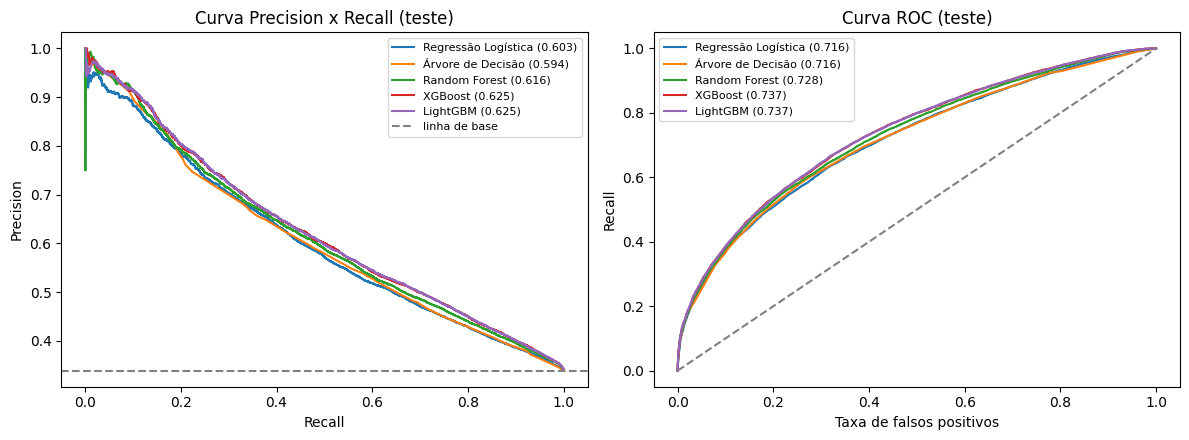

In [15]:
fig, eixos = plt.subplots(1, 2, figsize=(12, 4.5))
for nome in NOMES_MODELOS:
    p, r, _ = precision_recall_curve(y_test, prob_teste[nome])
    eixos[0].plot(r, p, label=f"{nome} ({average_precision_score(y_test, prob_teste[nome]):.3f})")
    fpr, tpr, _ = roc_curve(y_test, prob_teste[nome])
    eixos[1].plot(fpr, tpr, label=f"{nome} ({roc_auc_score(y_test, prob_teste[nome]):.3f})")
eixos[0].axhline(y_test.mean(), color="gray", linestyle="--", label="linha de base")
eixos[0].set_xlabel("Recall"); eixos[0].set_ylabel("Precision"); eixos[0].set_title("Curva Precision x Recall (teste)")
eixos[1].plot([0, 1], [0, 1], color="gray", linestyle="--")
eixos[1].set_xlabel("Taxa de falsos positivos"); eixos[1].set_ylabel("Recall"); eixos[1].set_title("Curva ROC (teste)")
for ax in eixos:
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

#### Interpretação

<p>No teste, com alunos que o modelo nunca viu, o PR-AUC fica entre 0,5941 (Árvore de Decisão) e 0,6251 (XGBoost), com LightGBM em 0,6250, Random Forest em 0,6160 e Regressão Logística em 0,6027, contra a linha de base de 0,339 (cerca de 1,8 vez). O ROC-AUC vai de 0,7157 a 0,7371. A ordem dos modelos é a mesma da validação cruzada (os dois de boosting no topo, a Regressão Logística e a Árvore no fim), e o valor do LightGBM no teste (0,6250) é até um pouco maior que o de fora da dobra no treino (0,6182), o que indica que não houve otimismo nem sobreajuste, e que o modelo generaliza para alunos novos.</p>
<p>No threshold de 0,5 o recall dos modelos fica entre 0,5743 e 0,6218 e a precision entre 0,5199 e 0,5359, ou seja, todos se comportam de forma parecida quando tem o mesmo peso de classe, e a diferença entre eles está mais na ordenação do que no ponto de operação. Respondendo a primeira pergunta estratégica, o histórico recente permite prever o erro acima da linha de base (PR-AUC de 0,625 contra 0,339), mas o poder de previsão é moderado, e a maior parte dos erros não é antecipável só com acerto e tentativas passadas.</p>

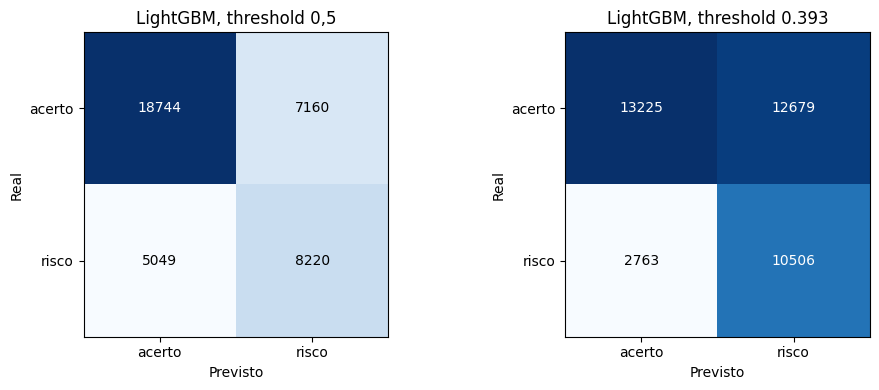

,threshold,recall,precision,F1,alarmes (% das interações)
0,0.500,0.619,0.534,0.574,0.393
1,0.393,0.792,0.453,0.576,0.592


In [16]:
def plotar_matriz_confusao(y_real, y_previsto, titulo, ax):
    matriz = confusion_matrix(y_real, y_previsto)
    ax.imshow(matriz, cmap="Blues")
    ax.set_xticks([0, 1], ["acerto", "risco"]); ax.set_yticks([0, 1], ["acerto", "risco"])
    ax.set_xlabel("Previsto"); ax.set_ylabel("Real"); ax.set_title(titulo)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, matriz[i, j], ha="center", va="center", color="white" if matriz[i, j] > matriz.max() / 2 else "black")

pipe_final = modelos_finais[modelo_escolhido]
prob_final = prob_teste[modelo_escolhido]
prev_padrao = (prob_final >= 0.5).astype(int)
prev_ajustada = (prob_final >= limiar_escolhido).astype(int)

fig, eixos = plt.subplots(1, 2, figsize=(10, 4))
plotar_matriz_confusao(y_test, prev_padrao, f"{modelo_escolhido}, threshold 0,5", eixos[0])
plotar_matriz_confusao(y_test, prev_ajustada, f"{modelo_escolhido}, threshold {limiar_escolhido:.3f}", eixos[1])
plt.tight_layout()
plt.show()

comparativo = pd.DataFrame({
    "threshold": [0.5, limiar_escolhido],
    "recall": [recall_score(y_test, p) for p in (prev_padrao, prev_ajustada)],
    "precision": [precision_score(y_test, p) for p in (prev_padrao, prev_ajustada)],
    "F1": [f1_score(y_test, p) for p in (prev_padrao, prev_ajustada)],
    "alarmes (% das interações)": [p.mean() for p in (prev_padrao, prev_ajustada)],
})
comparativo.round(3)

#### Interpretação

<p>Aplicando no teste o threshold escolhido no treino (0,393), o recall é 0,792 e a precision é 0,453, contra recall de 0,619 e precision de 0,534 no threshold de 0,5. O F1 fica igual nos dois casos (0,576 contra 0,574), e o modelo sinaliza 59,2% das interações no threshold ajustado contra 39,3% no padrão. O recall no teste (0,792) ficou um pouco abaixo da meta de 0,80, uma diferença de 0,008 que mostra que o threshold escolhido no treino se transfere bem para alunos novos, mas sem garantir a meta exatamente.</p>
<p>Na prática isso quer dizer que o sistema deixaria de detectar cerca de 21% dos casos de risco (1 menos 0,792) e que 54,7% dos alarmes seriam falsos (1 menos 0,453). Sinalizar quase 6 em cada 10 exercícios tem um risco real de fadiga de alertas (o professor deixa de olhar), o que indica que o sinal do modelo deve ser usado como filtro de atenção, combinado com outros sinais (como o peso do Grafo de Conhecimento do Núcleo 2 e a pulseira biométrica), e não como uma decisão automática de adaptar a atividade.</p>

<h2>Explicabilidade com SHAP</h2>
<p>Um modelo que prevê risco sem explicar tem utilidade limitada em um contexto pedagógico, porque o professor precisa entender por que o sistema sinalizou risco para agir sobre a causa e não só sobre o alarme. O SHAP (SHapley Additive exPlanations) atribui a cada feature uma parcela do afastamento da previsão em relação à média do modelo, com base em teoria dos jogos. A explicação é feita sobre o modelo escolhido, em uma amostra do teste para não pesar no tempo de execução.</p>

In [17]:
import shap

X_amostra = X_test.sample(n=5000, random_state=42)
X_amostra_transformada = pipe_final[:-1].transform(X_amostra)
explicador = shap.TreeExplainer(pipe_final.named_steps["modelo"])
valores_shap = explicador.shap_values(X_amostra_transformada)
if isinstance(valores_shap, list):
    valores_shap = valores_shap[1]
elif getattr(valores_shap, "ndim", 2) == 3:
    valores_shap = valores_shap[:, :, 1]

FEATURES_MODELO = list(X_amostra_transformada.columns)
importancia_media = pd.Series(np.abs(valores_shap).mean(axis=0), index=FEATURES_MODELO).sort_values(ascending=False)
print("Importância média (valor absoluto do SHAP) das 12 features mais importantes:")
print(importancia_media.head(12).round(4))
print()
print("Features de menor importância:")
print(importancia_media.tail(4).round(5))

Importância média (valor absoluto do SHAP) das 12 features mais importantes:
taxa_acerto_na_habilidade             0.3521
taxa_acerto_historica                 0.2149
sequencia_erros_anterior              0.1931
n_tentativas_habilidade_anteriores    0.1243
choose_1                              0.1233
dificuldade_habilidade                0.1136
taxa_acerto_recente                   0.1006
tentativas_media_recente              0.0520
posicao                               0.0412
tentativas_media_historica            0.0354
algebra                               0.0237
tendencia_desempenho                  0.0141
dtype: float64

Features de menor importância:
volatilidade_recente    0.00196
fill_in_1               0.00150
choose_n                0.00002
open_response           0.00000
dtype: float64


#### Interpretação

<p>As features de maior importância média (em valor absoluto do SHAP, na escala de log-odds do modelo) são taxa_acerto_na_habilidade (0,3521), taxa_acerto_historica (0,2149) e sequencia_erros_anterior (0,1931), seguidas de n_tentativas_habilidade_anteriores (0,1243), choose_1 (0,1233), dificuldade_habilidade (0,1136) e taxa_acerto_recente (0,1006). As de menor importância são volatilidade_recente (0,00196), fill_in_1 (0,0015), choose_n (0,00002) e open_response (0,0).</p>
<p>As três primeiras são interpretáveis em termos pedagógicos, pois dizem que o risco de errar cresce quando a criança vem errando naquele tipo de exercício, errou muito desde o começo ou acabou de errar várias vezes seguidas. A quantidade de prática na habilidade (0,1243) também pesa, o que confirma que a confiabilidade da taxa por habilidade é, ela mesma, uma informação útil, e a dificuldade da habilidade (0,1136) mostra que existe um efeito do exercício além do desempenho do aluno. A posicao (0,0412, usada como proxy de fadiga) tem peso pequeno, e uma hipótese é que ela conte os exercícios desde o início da sequência inteira e não dentro de uma sessão, o que enfraquece a ideia de fadiga (sessões não estão marcadas no dataset).</p>
<p>A hipótese de que a instabilidade do desempenho recente (volatilidade_recente) acrescentaria sinal além da taxa recente não se confirmou (importância de 0,002), e choose_n e open_response tem peso praticamente zero, como era esperado por terem só 67 e 8 linhas. Respondendo a quarta pergunta estratégica, as variáveis que mais influenciam são interpretáveis e coerentes com o objetivo.</p>

<h1>Fase 6 Deployment</h1>

<h2>Cards explicáveis em duas linguagens</h2>
<p>A mesma explicação SHAP precisa de dois registros de linguagem: o professor lida com terminologia pedagógica e pode interpretar um valor de contribuição diretamente, enquanto o responsável pela criança não tem por que conhecer o vocabulário técnico do modelo. A função abaixo traduz a mesma previsão nos dois formatos, a partir dos mesmos valores SHAP (a explicação é a mesma e só muda a linguagem).</p>

In [18]:
# cada feature tem uma frase para quando a contribuição SHAP aumenta o risco e outra para quando reduz,
# porque "o quão difícil o exercício costuma ser reduziu o risco" não faz sentido para um responsável
TRADUCAO_FEATURE = {
    "taxa_acerto_historica": ("a criança tem acertado pouco desde o início", "a criança tem acertado bastante desde o início"),
    "taxa_acerto_recente": ("a criança tem acertado pouco nas últimas tentativas", "a criança tem acertado bastante nas últimas tentativas"),
    "taxa_acerto_na_habilidade": ("a criança tem acertado pouco nesse tipo de exercício", "a criança tem acertado bastante nesse tipo de exercício"),
    "sequencia_erros_anterior": ("a criança acabou de errar vários exercícios seguidos", "a criança não está errando em sequência"),
    "dificuldade_habilidade": ("esse tipo de exercício costuma ser difícil para as crianças em geral", "esse tipo de exercício costuma ser fácil para as crianças em geral"),
    "tentativas_media_recente": ("a criança tem precisado de muitas tentativas recentemente", "a criança tem precisado de poucas tentativas recentemente"),
    "tentativas_media_historica": ("a criança costuma precisar de muitas tentativas", "a criança costuma precisar de poucas tentativas"),
}
DESCRICAO_NEUTRA = {
    "n_tentativas_habilidade_anteriores": "quantas vezes a criança já praticou esse tipo de exercício",
    "posicao": "quantos exercícios a criança já fez",
    "tendencia_desempenho": "se o desempenho da criança está melhorando ou piorando",
    "volatilidade_recente": "o quanto o desempenho da criança tem variado",
    "choose_1": "o formato de resposta do exercício (escolher uma alternativa)",
    "algebra": "o formato de resposta do exercício (resposta em forma de expressão)",
}

def frase_do_fator(feature, contribuicao):
    if feature in TRADUCAO_FEATURE:
        return TRADUCAO_FEATURE[feature][0 if contribuicao > 0 else 1]
    descricao = DESCRICAO_NEUTRA.get(feature, feature)
    return f"{descricao} ({'aumentou' if contribuicao > 0 else 'reduziu'} o risco)"

def gerar_card_explicativo(indice, limiar):
    valores = valores_shap[indice]
    probabilidade = float(pipe_final.predict_proba(X_amostra.iloc[[indice]])[0, 1])
    contribuicoes = sorted(zip(FEATURES_MODELO, valores), key=lambda item: abs(item[1]), reverse=True)
    principal, valor = contribuicoes[0]
    return {
        "tecnico": {
            "probabilidade_risco": round(probabilidade, 3), "sinaliza_risco": probabilidade >= limiar,
            "top3_contribuicoes_shap": {f: round(float(v), 3) for f, v in contribuicoes[:3]},
        },
        "acessivel": f"Risco de errar nesta atividade: {probabilidade:.0%}. Principal motivo: {frase_do_fator(principal, valor)}.",
    }

probabilidades_amostra = pipe_final.predict_proba(X_amostra)[:, 1]
for rotulo, indice in [("maior risco da amostra", int(np.argmax(probabilidades_amostra))),
                       ("menor risco da amostra", int(np.argmin(probabilidades_amostra)))]:
    card = gerar_card_explicativo(indice, limiar_escolhido)
    print(f"--- {rotulo} ---")
    print("Card técnico (professor):", card["tecnico"])
    print("Card acessível (responsável):", card["acessivel"])
    print()

--- maior risco da amostra ---
Card técnico (professor): {'probabilidade_risco': 0.997, 'sinaliza_risco': True, 'top3_contribuicoes_shap': {'sequencia_erros_anterior': 2.37, 'taxa_acerto_na_habilidade': 1.351, 'taxa_acerto_historica': 0.993}}
Card acessível (responsável): Risco de errar nesta atividade: 100%. Principal motivo: a criança acabou de errar vários exercícios seguidos.

--- menor risco da amostra ---
Card técnico (professor): {'probabilidade_risco': 0.007, 'sinaliza_risco': False, 'top3_contribuicoes_shap': {'dificuldade_habilidade': -1.764, 'choose_1': -1.284, 'algebra': -0.644}}
Card acessível (responsável): Risco de errar nesta atividade: 1%. Principal motivo: esse tipo de exercício costuma ser fácil para as crianças em geral.



#### Interpretação

<p>O card técnico do professor traz a probabilidade de risco, se o modelo sinaliza risco no threshold escolhido (0,393) e as 3 maiores contribuições SHAP. No exemplo de maior risco da amostra a probabilidade é 0,997, com sequencia_erros_anterior (+2,37), taxa_acerto_na_habilidade (+1,351) e taxa_acerto_historica (+0,993) empurrando para cima, e o card acessível traduz isso como "a criança acabou de errar vários exercícios seguidos". No exemplo de menor risco a probabilidade é 0,007, com dificuldade_habilidade (-1,764), choose_1 (-1,284) e algebra (-0,644) puxando para baixo, e o texto diz que "esse tipo de exercício costuma ser fácil para as crianças em geral". Os dois cards vêm dos mesmos valores SHAP e só muda a linguagem.</p>
<p>Os valores SHAP estão na escala de log-odds do LightGBM, então +2,37 não quer dizer 237% de risco, e sim o quanto aquela feature empurrou a previsão em relação à média do modelo. Uma correção que foi necessária: na primeira versão a frase dizia que o "quão difícil o exercício costuma ser" reduziu o risco, o que confunde um responsável, e por isso cada feature agora tem uma frase para quando aumenta o risco e outra para quando reduz. Como limitação, os dois exemplos são os extremos da amostra (o maior e o menor risco), e nos casos do meio, com probabilidade entre 0,3 e 0,6, as contribuições são menos claras e o motivo principal pode convencer menos. Também é melhor mostrar ao responsável faixas (baixo, médio e alto) em vez de um número como 100% (que aqui é o arredondamento de 0,997), para não passar a ideia de certeza que o modelo não tem.</p>

<h2>Conclusão e recomendação</h2>

<p><b>O que os dados permitiram concluir, pergunta por pergunta:</b></p>
<p><b>1. O histórico recente é suficiente para prever a próxima tentativa acima da linha de base?</b> Acima sim, mas com poder moderado: no teste o PR-AUC do melhor modelo é 0,625 contra 0,339 da linha de base (cerca de 1,8 vez), e o ROC-AUC é 0,737. A maior parte dos erros não é antecipável só com acerto e tentativas passadas.</p>
<p><b>2. Um modelo não linear supera uma referência simples e a Regressão Logística?</b> Supera, por margem pequena: boosting (XGBoost 0,6251 e LightGBM 0,6250, empatados) contra Random Forest 0,6160, Regressão Logística 0,6027 e Árvore de Decisão 0,5941.</p>
<p><b>3. É preciso corrigir o modelo para priorizar o recall?</b> Sim. Sem ajuste o recall da classe de risco no threshold padrão é 0,35 (fora da dobra no treino), com peso de classe sobe para 0,62, e com o threshold de 0,393 chega a 0,792 no teste (a meta era 0,80). O custo é uma precision de 0,453 e alarmes em 59,2% das interações.</p>
<p><b>4. Quais variáveis mais influenciam?</b> Acerto na habilidade (0,3521), acerto histórico (0,2149) e sequência de erros (0,1931), todas interpretáveis, e a volatilidade recente não acrescentou sinal (0,002).</p>

<p><b>Recomendação do que fazer no sistema agora:</b></p>
<p><b>1.</b> Usar a previsão como um filtro de atenção para o professor, e nunca como decisão automática de adaptar a atividade. Com 54,7% de alarmes falsos no threshold ajustado, ativar alertas automáticos para a criança causaria fadiga de alertas.</p>
<p><b>2.</b> Combinar o sinal com o peso do Grafo de Conhecimento (Núcleo 2) e com a pulseira biométrica antes de disparar qualquer ação, porque cada sinal sozinho é fraco, e a concordância entre eles deve reduzir o ruído.</p>
<p><b>3.</b> Definir o threshold junto com a equipe pedagógica, estimando o custo real de cada tipo de erro. Se a capacidade do professor for limitada, o threshold de 0,5 (recall de 0,619 e alarmes em 39,3% das interações) é uma alternativa.</p>
<p><b>4.</b> Nos cards para responsáveis, falar em "risco de errar" e não em "frustração", pois o alvo é um proxy comportamental (erro na próxima tentativa) e não o estado emocional da criança.</p>

<p><b>O que falta em dados para chegar em um resultado melhor:</b></p>
<p><b>Tempo entre tentativas e latência por tentativa:</b> o ASSISTments 2009 não tem timestamp, e é o sinal mais citado para frustração em sistemas tutores. O contrato TelemetryEvent do sistema (duration_ms e timestamp) vai fornecer isso.</p>
<p><b>Sessões marcadas:</b> para separar fadiga dentro de uma sessão de exercício da posição na sequência inteira (posicao hoje conta desde o início, e por isso tem pouco peso).</p>
<p><b>Rótulo real de frustração:</b> hoje o alvo é o erro. Para validar o proxy, seria preciso cruzar com abandono, pedido de dica (abandoned e hint_requested do TelemetryEvent), anotação do professor e o sinal da pulseira (BPM e GSR).</p>
<p><b>Dados de crianças neurodivergentes:</b> o dataset é de alunos em geral de outro sistema, então os números validam a técnica e não o desempenho esperado com as crianças do CogniKids.</p>
<p><b>Custo relativo dos erros:</b> a meta de recall de 0,80 foi fixada sem essa análise, e só o uso em produção com a equipe pedagógica permite estimar.</p>
<p><b>Cobertura de alunos novos:</b> o modelo exige 5 interações de histórico e deixa de fora 16,8% dos alunos, e o cold start precisa de outra abordagem (por exemplo, o perfil configurado previamente).</p>
<p>Outras limitações desta versão: os hiperparâmetros foram fixados de forma conservadora, sem busca sistemática (uma busca é o item de maior potencial de ganho, principalmente nos modelos de boosting), o tamanho da janela recente (5 tentativas) foi escolhido por convenção, e a ordem das listas do dataset foi assumida como cronológica sem confirmação.</p>

<p><b>ESSE NOTEBOOK FOI FEITO COM IA PARA O NOSSO APRENDIZADO E CONFORTO MENTAL, ASSIM VAI FICAR CLARO QUE NÃO FOMOS NÓS QUE FIZEMOS SEM ATRAPALHAR O APRENDIZADO DELAS.</b></p>